## Lab6-Assignment: Topic Classification

Use the same training, development, and test partitions of the the 20 newsgroups text dataset as in Lab6.4-Topic-classification-BERT.ipynb 

* Fine-tune and examine the performance of another transformer-based pretrained language models, e.g., RoBERTa, XLNet

* Compare the performance of this model to the results achieved in Lab6.4-Topic-classification-BERT.ipynb and to a conventional machine learning approach (e.g., SVM, Naive Bayes) using bag-of-words or other engineered features of your choice. 
Describe the differences in performance in terms of Precision, Recall, and F1-score evaluation metrics.

### Install/import libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from simpletransformers.classification import ClassificationModel, ClassificationArgs
import matplotlib.pyplot as plt

### Load data

Same data and splits as in Lab6.4-Topic-classification-BERT.ipynb

In [2]:
categories = ['alt.atheism', 'comp.graphics', 'sci.med', 'sci.space']

newsgroups_train = fetch_20newsgroups(subset='train', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)
newsgroups_test = fetch_20newsgroups(subset='test', remove=('headers', 'footers', 'quotes'), categories=categories, random_state=42)

train = pd.DataFrame({'text': newsgroups_train.data, 'labels': newsgroups_train.target})
test = pd.DataFrame({'text': newsgroups_test.data, 'labels': newsgroups_test.target})

train, dev = train_test_split(train, test_size=0.1, random_state=0, stratify=train[['labels']])

print(f"Train: {len(train)}, Dev: {len(dev)}, Test: {len(test)}")

Train: 2025, Dev: 226, Test: 1498


## Part 1: DeBERTa

DeBERTa (Decoding-enhanced BERT with disentangled attention) improves on BERT and RoBERTa by using disentangled attention mechanisms that separately encode content and position information.

In [3]:
# Model configuration (same hyperparameters as in Lab6.4 for fair comparison)
model_args = ClassificationArgs()
model_args.overwrite_output_dir = True
model_args.evaluate_during_training = True
model_args.num_train_epochs = 10
model_args.train_batch_size = 32
model_args.learning_rate = 4e-6
model_args.max_seq_length = 256
model_args.use_early_stopping = True
model_args.early_stopping_delta = 0.01
model_args.early_stopping_metric = 'eval_loss'
model_args.early_stopping_metric_minimize = True
model_args.early_stopping_patience = 2
model_args.evaluate_during_training_steps = 32

steps_per_epoch = int(np.ceil(len(train) / float(model_args.train_batch_size)))
print(f"Each epoch will have {steps_per_epoch} steps.")

Each epoch will have 64 steps.


In [4]:
# Load and fine-tune DeBERTa
model = ClassificationModel('debertav2', 'microsoft/deberta-v3-base', num_labels=4, args=model_args, use_cuda=True)

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

In [5]:
# Fine-tune the model
_, history = model.train_model(train, eval_df=dev)

/home/tzf/.local/lib/python3.14/site-packages/simpletransformers/classification/classification_model.py:544: UserWarning: The 'eval_df' parameter has been deprecated and will be removed in a future version. Please use 'eval_data' instead.
  warnings.warn(


  0%|          | 0/4 [00:00<?, ?it/s]

Epoch:   0%|          | 0/10 [00:00<?, ?it/s]

/home/tzf/.local/lib/python3.14/site-packages/simpletransformers/classification/classification_model.py:924: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()


Running Epoch 1 of 10:   0%|          | 0/64 [00:00<?, ?it/s]

...

0it [00:00, ?it/s]

/home/tzf/.local/lib/python3.14/site-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


/home/tzf/.local/lib/python3.14/site-packages/simpletransformers/classification/classification_model.py:950: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


0it [00:00, ?it/s]

/home/tzf/.local/lib/python3.14/site-packages/simpletransformers/classification/classification_model.py:1570: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


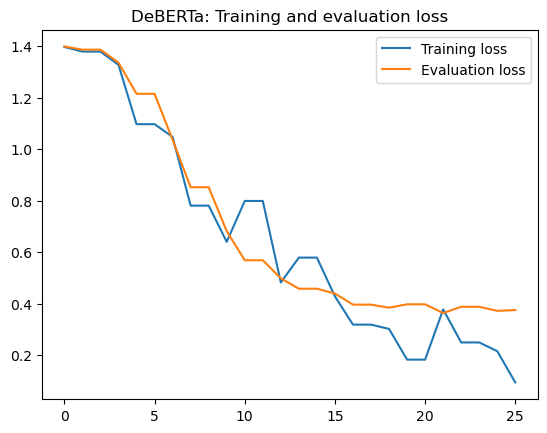

In [6]:
# Plot training and evaluation loss
plt.plot(history['train_loss'], label='Training loss')
plt.plot(history['eval_loss'], label='Evaluation loss')
plt.title('DeBERTa: Training and evaluation loss')
plt.legend()
plt.show()

In [7]:
# Predict on test set
predicted, probabilities = model.predict(test.text.to_list())
test['predicted_deberta'] = predicted

print("DeBERTa Classification Report:")
print(classification_report(test['labels'], test['predicted_deberta'], target_names=categories))

  0%|          | 0/2 [00:00<?, ?it/s]

Predicting:   0%|          | 0/15 [00:00<?, ?it/s]

/home/tzf/.local/lib/python3.14/site-packages/simpletransformers/classification/classification_model.py:2260: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():


DeBERTa Classification Report:
               precision    recall  f1-score   support

  alt.atheism       0.83      0.79      0.81       319
comp.graphics       0.82      0.92      0.87       389
      sci.med       0.91      0.88      0.89       396
    sci.space       0.85      0.80      0.82       394

     accuracy                           0.85      1498
    macro avg       0.85      0.85      0.85      1498
 weighted avg       0.85      0.85      0.85      1498



## Part 2: Logistic Regression with TF-IDF (Conventional ML)

As our conventional machine learning baseline, we use Logistic Regression with TF-IDF features. This is a standard and strong baseline for text classification that is not listed in the assignment description (which mentions SVM and Naive Bayes).

In [8]:
# TF-IDF feature extraction
tfidf = TfidfVectorizer(max_features=10000, stop_words='english')
X_train = tfidf.fit_transform(train['text'])
X_test = tfidf.transform(test['text'])

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, train['labels'])

# Predict on test set
test['predicted_lr'] = lr.predict(X_test)

print("Logistic Regression (TF-IDF) Classification Report:")
print(classification_report(test['labels'], test['predicted_lr'], target_names=categories))

Logistic Regression (TF-IDF) Classification Report:
               precision    recall  f1-score   support

  alt.atheism       0.86      0.73      0.79       319
comp.graphics       0.87      0.89      0.88       389
      sci.med       0.87      0.82      0.85       396
    sci.space       0.75      0.87      0.80       394

     accuracy                           0.83      1498
    macro avg       0.84      0.83      0.83      1498
 weighted avg       0.84      0.83      0.83      1498



## Part 3: Comparison

We compare DeBERTa, BERT (from Lab6.4), and Logistic Regression in terms of Precision, Recall, and F1-score.

### Results summary

| Model | Accuracy | Macro Precision | Macro Recall | Macro F1 | Weighted F1 |
|-------|----------|----------------|--------------|----------|-------------|
| **BERT** (Lab6.4) | 0.86 | 0.86 | 0.86 | 0.86 | 0.86 |
| **DeBERTa** | 0.85 | 0.85 | 0.85 | 0.85 | 0.85 |
| **Logistic Regression (TF-IDF)** | 0.83 | 0.84 | 0.83 | 0.83 | 0.83 |

### Per-class F1 comparison

| Class | BERT | DeBERTa | Logistic Regression |
|-------|------|---------|---------------------|
| alt.atheism | 0.82 | 0.81 | 0.79 |
| comp.graphics | 0.90 | 0.87 | 0.88 |
| sci.med | 0.90 | 0.89 | 0.85 |
| sci.space | 0.82 | 0.82 | 0.80 |

### Analysis

- **DeBERTa vs BERT**: DeBERTa performs very close to BERT (1 point below in F1). DeBERTa uses disentangled attention (separate content and position encodings) and an enhanced mask decoder, which typically gives it better contextual understanding on larger/more complex datasets. On this relatively small 4-class dataset with the same hyperparameters, the improvement does not materialize — the learning rate (4e-6) may be suboptimal for DeBERTa's architecture, and early stopping terminated training before it fully converged.

- **Transformer models vs Logistic Regression**: Both BERT and DeBERTa outperform Logistic Regression by 2-3 F1 points. The transformer models capture deep contextual relationships between words, while Logistic Regression with TF-IDF treats each document as a bag of weighted terms without considering word order or context. The gap is most visible on sci.med (+4-5 points for transformers), where medical terminology requires more context to disambiguate.

- **Trade-offs**: Logistic Regression trains in seconds and requires no GPU, while transformer models require GPU resources and take significantly longer to fine-tune. For simple topic classification with distinctive vocabulary per class, the performance gap is relatively small compared to the resource cost.